Notebook to check different spatio-temporal aggregation of the data

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx
import holidays
import datetime as dt
import warnings
warnings.filterwarnings("ignore")

In [106]:
# read data
df = pd.read_parquet('C:/Users/luisa/Desktop/thesis_project/data/tripsv3_augmented.parquet') 

# discard unrelevant columns
df = df[['trip_start', 'trip_origin_latitude', 'trip_origin_longitude', 'unique_id', 
  # poi
  'leisure', 'public_services', 'building', 'education', 'food', 'transport',
  'finantial', 'healthcare', 'office', 'shop', 'tourism', 
  # meteo
  'totalSnow_cm', 'windspeedKmph', 'tempC', 'visibility', 'precipMM', 
  # add temporal factors
  'name_day', 'holiday']]

In [107]:
# round timestamp to hour
df.trip_start = df.trip_start.dt.round(freq='H').dt.tz_convert(None)

In [ ]:
# generalize coordinates by rounding at 3rd decimal
df['trip_origin_latitude'] = df.trip_origin_latitude.round(decimals = 2)
df['trip_origin_longitude'] = df.trip_origin_longitude.round(decimals = 2)
df.rename(columns = {'trip_origin_longitude':'lon', 'trip_origin_latitude':'lat', 'trip_start':'time'}, inplace = True)

# compute counts
# and get avg num pois (~ poi count per pt)
df = df.groupby(['lat', 'lon', 'time']).aggregate({'unique_id':['count'],
            # 'leisure':['mean'], 
            # 'public_services':['mean'], 'building':['mean'], 
            # 'education':['mean'], 'food':['mean'], 
            # 'transport':['mean'], 'finantial':['mean'], 
            # 'healthcare':['mean'], 'office':['mean'], 
            # 'shop':['mean'], 'tourism':['mean'], 
            }).reset_index()
df.columns = df.columns.droplevel(1)
df.rename(columns = {'unique_id':'trips_count'}, inplace = True)


# ADD MISSING TIMESTAMPS
# add zero counts / missing times bc no trip was made
# for each location

# since freq='H' is the min freq used in this project, use that, then can aggregate times if needed
freq = 'H'
# time interavals
all_times = pd.DataFrame({'time': pd.date_range(df.time.min(), df.time.max(), freq=freq)})

final_df = pd.DataFrame({'time':[]})
df['latlon'] = df.lat.astype(str) +';'+ df.lon.astype(str)
for coord in df['latlon'].unique():
  x = float(coord.split(';')[0])
  y = float(coord.split(';')[1])
  gh_df = df[(df['lat']==x) & (df['lon']==y)][['trips_count', 'time']]
  gh_all_times = pd.merge(all_times, gh_df, left_on='time', right_on='time', how='left')#.fillna(0)
  # AGGREGATE ON "freq" LEVEL -> already done if freq="H", necessary only if hours further aggregated
  gh_all_times = gh_all_times.groupby([pd.Grouper(key='time', freq=freq)]).sum() 
  gh_all_times['lat'] = x
  gh_all_times['lon'] = y
  gh_all_times = gh_all_times.reset_index()
  final_df = final_df.append(gh_all_times)


# fill trips count with 0 when there were no trips
df = final_df 
df.trips_count = df.trips_count.fillna(0)


# add weather info
weather = pd.read_csv('C:/Users/luisa/Desktop/thesis_project/data/weather_info.csv')
weather = weather[['date_time', 'totalSnow_cm', 'windspeedKmph', 'tempC', 'visibility', 'precipMM']]

weather['date_time'] = pd.to_datetime(weather.date_time, format="%Y-%m-%d %H:%M:%S")

df['time'] = pd.to_datetime(df.time, format="%Y-%m-%d %H:%M:%S")

df = df.merge(weather, left_on=['time'], right_on=['date_time'])
df = df.drop(['date_time'], axis=1)

# sort by timestamp
df = df.sort_values(by=['time'])
df = df.reset_index(drop=True)

# add temporal factos
df['date'] = df.time.dt.date
df['year'] = df.time.dt.year
df['month'] = df.time.dt.month
df['day'] = df.time.dt.day
df['hour'] = df.time.dt.hour
df['weekday'] = df.time.dt.weekday

# save data
df.to_csv('idw-data_hourly_all_times.csv')


df


In [88]:
df.trips_count.mean(), df.trips_count.max(), df.trips_count.min()

(0.23415858534537984, 18.0, 0.0)

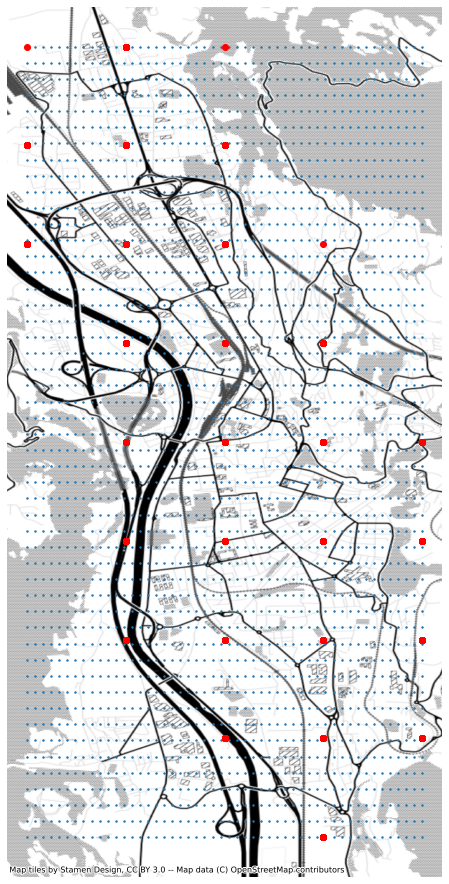

In [4]:
# create geodataframe for plotting 
# lat and lon rounded at 1 decimal
gdf = gpd.GeoDataFrame(df, crs='EPSG:4326', geometry=gpd.points_from_xy(df.lon, df.lat))

# extract bounding box of all locations in the dataset, 
# namely all the area of Trento where allowed e-scooters movements have been recorded
xmin, ymin, xmax, ymax = gdf.total_bounds
# produce all the longitude-latitude coordinates within the bounding box,
# with the final result of creating a grid in which the city is divided
x, y = np.meshgrid( np.linspace(xmin, xmax), np.linspace(ymin, ymax) )

# flatten x and y to make them a simple vector (list) 
grid = np.column_stack((x.flatten(), y.flatten()))
# convert flattened x and y to a geodataframe
grid_df = gpd.GeoDataFrame( geometry=gpd.points_from_xy(x=x.flatten(), y=y.flatten()) )

# plot 
# plot all the points in the grid (blue points)
ax = grid_df.plot(markersize=2, figsize=(40,16)) 
# plot e-scooters observatios for starting points of trips
gdf.plot(ax=ax, color='red')
# basemap
ctx.add_basemap(
    ax, 
    crs=gdf.crs.to_string(), 
    source=ctx.providers.Stamen.TonerBackground
)
# remove axes
ax.set_axis_off()

Resample time: daily data

In [ ]:
# read data
df = pd.read_parquet('C:/Users/luisa/Desktop/thesis_project/data/tripsv3_augmented.parquet') 

# discard unrelevant columns
df = df[['trip_start', 'trip_origin_latitude', 'trip_origin_longitude', 'unique_id', 
  # poi
  'leisure', 'public_services', 'building', 'education', 'food', 'transport',
  'finantial', 'healthcare', 'office', 'shop', 'tourism', 
  # meteo
  'totalSnow_cm', 'windspeedKmph', 'tempC', 'visibility', 'precipMM', 
  # add temporal factors
  'name_day', 'holiday']]

# daily 
df.trip_start = df.trip_start.dt.round(freq='D').dt.tz_convert(None)

# generalize coordinates by rounding at 3rd decimal
df['trip_origin_latitude'] = df.trip_origin_latitude.round(decimals = 2)
df['trip_origin_longitude'] = df.trip_origin_longitude.round(decimals = 2)
df.rename(columns = {'trip_origin_longitude':'lon', 'trip_origin_latitude':'lat', 'trip_start':'time'}, inplace = True)

# compute counts
# and get avg num pois (~ poi count per pt)
df = df.groupby(['lat', 'lon', 'time']).aggregate({'unique_id':['count']})
df.columns = df.columns.droplevel(1)
df.rename(columns = {'unique_id':'trips_count'}, inplace = True)
df = df.reset_index()

# ADD MISSING DATES PER LOCATION (with 0 counts)
freq = 'D'
# time interavals
all_times = pd.DataFrame({'time': pd.date_range(df.time.min(), df.time.max(), freq=freq)})

final_df = pd.DataFrame({'time':[]})
df['latlon'] = df.lat.astype(str) +';'+ df.lon.astype(str)
for coord in df['latlon'].unique():
  x = float(coord.split(';')[0])
  y = float(coord.split(';')[1])
  gh_df = df[(df['lat']==x) & (df['lon']==y)][['trips_count', 'time']]
  gh_all_times = pd.merge(all_times, gh_df, left_on='time', right_on='time', how='left')#.fillna(0)
  # AGGREGATE ON "freq" LEVEL -> already done if freq="H", necessary only if hours further aggregated
  gh_all_times = gh_all_times.groupby([pd.Grouper(key='time', freq=freq)]).sum() 
  gh_all_times['lat'] = x
  gh_all_times['lon'] = y
  gh_all_times = gh_all_times.reset_index()
  final_df = final_df.append(gh_all_times)

df = final_df

# add weather info
weather = pd.read_csv('C:/Users/luisa/Desktop/thesis_project/data/weather_info.csv')
weather = weather[['date_time', 'totalSnow_cm', 'windspeedKmph', 'tempC', 'visibility', 'precipMM']]

weather['date_time'] = pd.to_datetime(weather.date_time, format="%Y-%m-%d %H:%M:%S")

df['time'] = pd.to_datetime(df.time, format="%Y-%m-%d %H:%M:%S")

df = df.merge(weather, left_on=['time'], right_on=['date_time'])
df = df.drop(['date_time'], axis=1)

# sort by timestamp
df = df.sort_values(by=['time'])
df = df.reset_index(drop=True)

# add temporal factos
df['date'] = df.time.dt.date
df['year'] = df.time.dt.year
df['month'] = df.time.dt.month
df['day'] = df.time.dt.day
df['weekday'] = df.time.dt.weekday

# save data
df.to_csv('idw-data_daily_all.csv')


df


#### Centroid cells precision=6 as coords

In [2]:
import geohash as pgh
df = pd.read_parquet('C:/Users/luisa/Desktop/thesis_project/data/tripsv3_augmented.parquet')

# get coordinates of centroid of cells (40) --> all decimals
lat, lon = [], []
for coords in df.apply(lambda df: pgh.decode(df['geohash_origin']), axis=1):
    lat.append(coords[0])
    lon.append(coords[1])
df['lat']=lat
df['lon']=lon

In [3]:
df['date'] = df.trip_start.dt.date

In [ ]:
df_cnt = df[['date', 'lat', 'lon', 'unique_id', 'geohash_origin']].groupby(['lat', 'lon', 'geohash_origin', 'date']).agg(['count']).reset_index()
df_cnt.columns = df_cnt.columns.droplevel(1)
df_cnt.rename(columns = {'unique_id':'trips_count'}, inplace = True)
df_cnt

In [5]:
# add temporal factos
df_cnt['year'] = [df_cnt.date[i].year for i in range(len(df_cnt))]
df_cnt['month'] = [df_cnt.date[i].month for i in range(len(df_cnt))]
df_cnt['day'] = [df_cnt.date[i].day for i in range(len(df_cnt))]
df_cnt['weekday'] = [df_cnt.date[i].weekday() for i in range(len(df_cnt))]

In [6]:
df_cnt = df_cnt.sort_values(by=['date']).reset_index(drop=True)

In [ ]:
df_cnt

In [8]:
df_cnt.to_csv('idw_data-gh-prec6.csv')

In [ ]:
df_cnt.trips_count.mean()

In [214]:
# epsg 32632 --> meters for italy zone
df_cnt = gpd.GeoDataFrame(df_cnt, crs='EPSG:4326', geometry=gpd.points_from_xy(df_cnt.lon, df_cnt.lat))
df_cnt = df_cnt.to_crs(epsg=32632)

In [216]:
df_cnt['lon'] = df_cnt.geometry.x
df_cnt['lat'] = df_cnt.geometry.y
df_cnt
# df_cnt.to_csv('idw_data-gh-prec6_meters.csv')

In [ ]:
df.date.nunique()